In [7]:
import json
import numpy as np 
from matplotlib import pyplot as plt

In [3]:
def read_data(model_name, dataset_name, layer, basis_name):
    
    with open(f"../../artifacts/2024-10-s41/experiments/accuracy-basis/run3-imagenet/{dataset_name}/{model_name}/{layer}/{basis_name}--uncentered/accuracy.json", "r") as fh:
        return json.load(fh)

read_data(model_name="imagenet-resnet18-tv", dataset_name="imagenet", layer="layer1", basis_name="pca")

{'accuracies': [0.0008399999933317304,
  0.0010000000474974513,
  0.011800000444054604,
  0.13142000138759613,
  0.22089999914169312,
  0.29071998596191406,
  0.3868600130081177,
  0.49775999784469604,
  0.5437999963760376,
  0.5698000192642212,
  0.5930799841880798,
  0.611840009689331,
  0.6315400004386902,
  0.649179995059967,
  0.6672199964523315,
  0.6740999817848206,
  0.6797999739646912,
  0.6975399851799011],
 'arr_ks': [1, 2, 4, 6, 8, 10, 12, 14, 16, 18, 20, 22, 24, 26, 28, 30, 32, 64],
 'aurocs': [[],
  [],
  [],
  [],
  [],
  [],
  [],
  [],
  [],
  [],
  [],
  [],
  [],
  [],
  [],
  [],
  [],
  []],
 'dims': 64,
 'losses': [7.668453693389893,
  8.128002166748047,
  7.353497505187988,
  5.140753269195557,
  4.142209529876709,
  3.62200665473938,
  2.9239752292633057,
  2.217984676361084,
  1.9747940301895142,
  1.8450168371200562,
  1.726940631866455,
  1.6352839469909668,
  1.5314909219741821,
  1.4534542560577393,
  1.3745368719100952,
  1.340977668762207,
  1.32071042060

FileNotFoundError: [Errno 2] No such file or directory: '../../artifacts/2024-10-s41/experiments/accuracy-basis/run3-imagenet/imagenet/imagenet-resnet18-tv/layer4/pca--uncentered/accuracy.json'

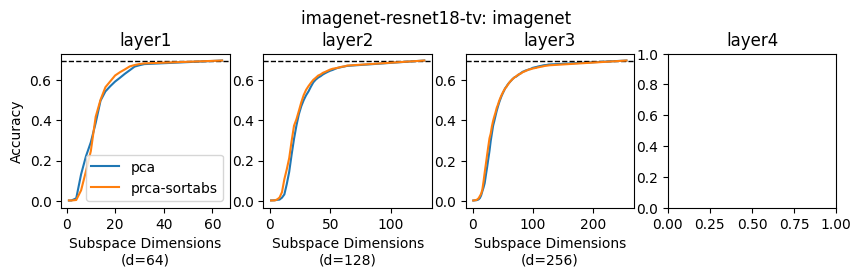

In [8]:
def viz(model_name, dataset_name, arr_layers=["layer1", "layer2", "layer3", "layer4:20"]):
    ncols = len(arr_layers)
    
    
    plt.figure(figsize=(2.5*ncols, 2))
    plt.suptitle(f"{model_name}: {dataset_name}", y=1.10)
    
    for lix, layer in enumerate(arr_layers):
        plt.subplot(1, ncols, lix +1)
        slugs = layer.split(":")
        if len(slugs) == 2:
            layer, K = slugs
            K = int(K)
        else:
            layer = slugs[0]
            K = None
        plt.title(layer)
        if lix == 0:
            plt.ylabel("Accuracy")
        for bix, basis_name in enumerate(["pca", "prca-sortabs"]):
            data = read_data(model_name, dataset_name, layer, basis_name)
            best_acc = data["original_accuracy"]
            arr_ks = np.array(data["arr_ks"])
            d = arr_ks[-1]
            arr_accs = np.array(data["accuracies"])
        
            if K is not None:
                selected = arr_ks <= K
                arr_ks = arr_ks[selected]
                arr_accs = arr_accs[selected]
            plt.plot(arr_ks, arr_accs, label=basis_name)
            if bix == 0:
                plt.axhline(best_acc, ls="--", lw=1, color="k")
        plt.xlabel(f"Subspace Dimensions\n(d={d})")
        if lix == 0:
            plt.legend()

viz("imagenet-resnet18-tv", "imagenet")